<a href="https://colab.research.google.com/github/PinkSoso/clinic-study-dropout-analysis/blob/main/Prediction_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#clinical_trial_model.py
import pandas as pd
import sqlite3
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

print("Loading dataset into SQLite database...")

#Load CSV

Loading dataset into SQLite database...


In [3]:
#Starting all over. Using an updated dataset with dummy variable this time - instead of labelencoder.

!pip install pandas scikit-learn joblib

In [7]:
from google.colab import files
uploaded = files.upload()  #Upload the CSV file you just provided

import pandas as pd

df = pd.read_csv("clinical_trial_dataset_1000.csv", sep=";")
print("✅ Dataset loaded")
df.head()

Saving clinical_trial_dataset_1000.csv to clinical_trial_dataset_1000 (3).csv
✅ Dataset loaded


,Participant_ID,Age,Gender,Ethnicity,Health_Condition,Comorbidities,Previous_Adherence_Score,Trial_Phase,Dropout_Flag,Dropout_Reason
0,P0001,58,Male,White,NaN,Arthritis,0.85,Phase I,No,NaN
1,P0002,32,Male,White,NaN,NaN,0.72,Phase I,No,NaN
2,P0003,55,Female,White,Diabetes,Obesity,0.70,Phase I,Yes,Lack of Improvement
3,P0004,50,Male,White,Asthma,Depression,0.70,Phase III,No,NaN
4,P0005,59,Female,Black,Heart Disease,Depression,1.00,Phase II,Yes,Medical Advice


In [8]:
print(df.columns.tolist())
print(df.shape)

['Participant_ID', 'Age', 'Gender', 'Ethnicity', 'Health_Condition', 'Comorbidities', 'Previous_Adherence_Score', 'Trial_Phase', 'Dropout_Flag', 'Dropout_Reason']
(1000, 10)


In [9]:
# Clean and inspect Dropout_Flag values
df["Dropout_Flag"] = df["Dropout_Flag"].str.strip().str.lower()

# Keep only rows with valid Yes/No labels
df = df[df["Dropout_Flag"].isin(["yes", "no"])]

# Convert Dropout_Flag to binary
df["Dropout_Flag"] = df["Dropout_Flag"].map({"yes": 1, "no": 0})

# Convert categorical features using dummy variables
categorical_cols = ["Gender", "Ethnicity", "Health_Condition", "Comorbidities", "Trial_Phase"]
df = pd.get_dummies(df, columns=categorical_cols)

# Drop unused columns
X = df.drop(columns=["Participant_ID", "Dropout_Reason", "Dropout_Flag"])
y = df["Dropout_Flag"]

print("✅ Data preprocessing done")

✅ Data preprocessing done


In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Class imbalanced model
model_balanced = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)
model_balanced.fit(X_train, y_train)

# Predictions
y_pred_balanced = model_balanced.predict(X_test)

print("📊 Classification Report (avec class_weight='balanced'):\n")
print(classification_report(y_test, y_pred_balanced))


print("✅ Model trained")

📊 Classification Report (avec class_weight='balanced'):

              precision    recall  f1-score   support

           0       0.72      0.93      0.81        73
           1       0.17      0.04      0.06        27

    accuracy                           0.69       100
   macro avg       0.45      0.48      0.44       100
weighted avg       0.57      0.69      0.61       100

✅ Model trained


In [14]:
print(df.shape)
print(df.dtypes)
print(df['Dropout_Flag'].value_counts())

# Si le modèle a bien été réentraîné sur les bonnes données :
import pandas as pd
importances = pd.Series(model_balanced.feature_importances_, index=X_train.columns)
print(importances.sort_values(ascending=False))

(1000, 23)
Participant_ID                     object
Age                                 int64
Previous_Adherence_Score          float64
Dropout_Flag                        int64
Dropout_Reason                     object
Gender_Female                        bool
Gender_Male                          bool
Ethnicity_Asian                      bool
Ethnicity_Black                      bool
Ethnicity_Hispanic                   bool
Ethnicity_White                      bool
Health_Condition_Asthma              bool
Health_Condition_Cancer              bool
Health_Condition_Diabetes            bool
Health_Condition_Heart Disease       bool
Health_Condition_Hypertension        bool
Comorbidities_Arthritis              bool
Comorbidities_Depression             bool
Comorbidities_Kidney Disease         bool
Comorbidities_Obesity                bool
Trial_Phase_Phase I                  bool
Trial_Phase_Phase II                 bool
Trial_Phase_Phase III                bool
dtype: object
Dropout_F

In [15]:
from sklearn.metrics import classification_report

# Récupère les probabilités au lieu des prédictions brutes
y_proba = model_balanced.predict_proba(X_test)[:, 1]

# Test avec un seuil plus bas (0.3 au lieu de 0.5 par défaut)
y_pred_threshold = (y_proba >= 0.3).astype(int)

print("Classification Report (seuil = 0.3):\n")
print(classification_report(y_test, y_pred_threshold))

Classification Report (seuil = 0.3):

              precision    recall  f1-score   support

           0       0.67      0.58      0.62        73
           1       0.16      0.22      0.19        27

    accuracy                           0.48       100
   macro avg       0.41      0.40      0.40       100
weighted avg       0.53      0.48      0.50       100



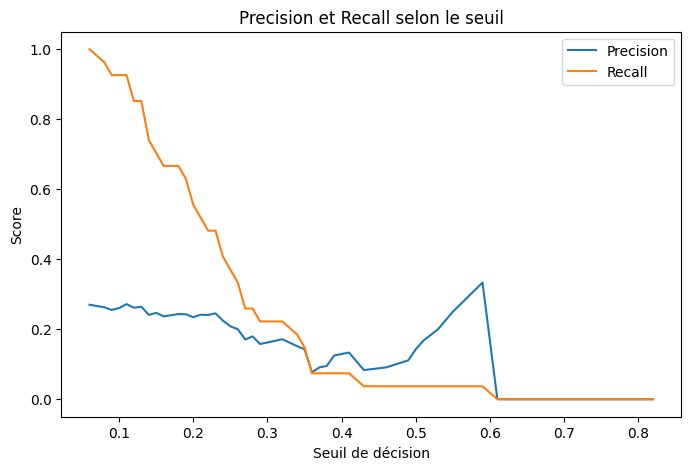

In [16]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(8,5))
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.xlabel("Seuil de décision")
plt.ylabel("Score")
plt.legend()
plt.title("Precision and Recall selon le seuil")
plt.show()

In [17]:
from sklearn.metrics import average_precision_score
pr_auc = average_precision_score(y_test, y_proba)
print(f"PR-AUC (Average Precision) : {pr_auc:.3f}")

PR-AUC (Average Precision) : 0.227


In [18]:
import joblib
joblib.dump(model, "dropout_model.pkl")
print("✅ Model saved as 'dropout_model.pkl'")

✅ Model saved as 'dropout_model.pkl'


In [19]:
new_data = pd.DataFrame([{
    "Age": 55,
    "Previous_Adherence_Score": 0.75,
    "Gender_Female": 0, "Gender_Male": 1,
    "Ethnicity_Asian": 0, "Ethnicity_Black": 0, "Ethnicity_Hispanic": 0, "Ethnicity_White": 1,
    "Health_Condition_Asthma": 0, "Health_Condition_Cancer": 0,
    "Health_Condition_Diabetes": 1, "Health_Condition_Heart Disease": 0, "Health_Condition_Hypertension": 0,
    "Comorbidities_Arthritis": 0, "Comorbidities_Depression": 0,
    "Comorbidities_Kidney Disease": 0, "Comorbidities_Obesity": 0,
    "Trial_Phase_Phase I": 0, "Trial_Phase_Phase II": 1, "Trial_Phase_Phase III": 0
}])

missing_cols = set(X.columns) - set(new_data.columns)
print("Colonnes manquantes, remplies à 0 :", missing_cols)  # devrait être vide ou presque

for col in missing_cols:
    new_data[col] = 0
new_data = new_data[X.columns]

prediction = model.predict(new_data)[0]
probability = model.predict_proba(new_data)[0][1]
print(f"\n🧪 Predicted Dropout: {'Yes' if prediction == 1 else 'No'}")
print(f"📈 Probability of Dropout: {round(probability * 100, 2)}%")

Colonnes manquantes, remplies à 0 : set()

🧪 Predicted Dropout: No
📈 Probability of Dropout: 28.0%


In [21]:
def predire_profil(overrides):
    base = {col: 0 for col in X.columns}
    base.update(overrides)
    df_profil = pd.DataFrame([base])[X.columns]
    proba = model.predict_proba(df_profil)[0][1]
    return round(proba * 100, 2)

profil_jeune = {"Age": 22, "Previous_Adherence_Score": 0.95, "Gender_Female": 1,
                "Ethnicity_White": 1, "Trial_Phase_Phase I": 1}

profil_age = {"Age": 82, "Previous_Adherence_Score": 0.20, "Gender_Male": 1,
              "Ethnicity_White": 1, "Trial_Phase_Phase III": 1}

print("Profil jeune, bonne adhérence :", predire_profil(profil_jeune), "%")
print("Profil âgé, faible adhérence :", predire_profil(profil_age), "%")

Profil jeune, bonne adhérence : 29.0 %
Profil âgé, faible adhérence : 47.0 %


In [22]:
print("Age - min/max réels :", df['Age'].min(), "-", df['Age'].max())
print("Adherence - min/max réels :", df['Previous_Adherence_Score'].min(), "-", df['Previous_Adherence_Score'].max())

# Combien de vrais participants ressemblent à votre profil "âgé, faible adhérence" ?
proche_profil_age = df[(df['Age'] >= 75) & (df['Previous_Adherence_Score'] <= 0.3)]
print("\nNombre de participants réels proches du profil 'âgé, faible adhérence' :", len(proche_profil_age))
print(proche_profil_age[['Age', 'Previous_Adherence_Score', 'Dropout_Flag']])

Age - min/max réels : 18 - 80
Adherence - min/max réels : 0.1 - 1.0

Nombre de participants réels proches du profil 'âgé, faible adhérence' : 1
     Age  Previous_Adherence_Score  Dropout_Flag
911   76                      0.17             0
